# Generatief model voor lichaamslengten
In deze notebook willen we een generatief model voor de lichaamslengten van mensen maken om nieuwe lichaamslengten mee te genereren. Dit is een erg eenvoudig voorbeeld van een generatief model voor een erg eenvoudig probleem. 

## De beschikbare data
De variabele `lengten_vrouwen` bevat de lengten van twintig vrouwen (van allerlei leeftijden). 

In [1]:
lengten_vrouwen = [87, 31, 185, 127, 55, 113, 160, 105, 116, 176]


Bereken het minimum en het maximum. 

In [4]:
import numpy as np
import pandas as pd

kortste = min(lengten_vrouwen) # min(lengten_vrouwen)
langste = max(lengten_vrouwen) # max(lengten_vrouwen)

display(kortste, langste)

31

185

Welke kansverdeling ken je die geparametriseerd wordt door alleen het minimum en het maximum? 

In [4]:
# Antwoord: de uniforme verdeling

Laat `V` een stochast zijn voor de lengte van een vrouw. We hebben nu een model voor `V`, dat wil zeggen, we hebben een schatting voor de verdeling van `V`: `P(V=v)`. Deze verdeling is geparameteriseerd door `kortste` en `langste`. 

In [5]:
parameters = [kortste, langste]

Genereer met deze volledig bekende verdeling nu tien nieuwe lengten van vrouwen. 

In [6]:
import random

def genereer_lengte_van_een_vrouw(parameters):
    return random.random() * (parameters[1]- parameters[0]) + parameters[0] # random.random() * (parameters[1] - parameters[0]) + parameters[0]

def genereer_lengten_van_vrouwen(aantal): return [genereer_lengte_van_een_vrouw(parameters) for vrouw in range(aantal)]

genereer_lengten_van_vrouwen(10)

[77.43385904905006,
 161.4748347707402,
 83.30941733525295,
 108.46603682853677,
 126.57581283979674,
 152.92746005051225,
 134.41515446021498,
 171.02536040508582,
 120.8373030286914,
 92.90654010492949]

Dit was generatieve AI! We hebben tien nieuwe data gegeneerd op basis van honderd voorbeelden. 

Er zijn echter problemen met dit model: 
1. het is op deze manier niet mogelijk om ooit nieuwe lengten te genereren die groter of kleiner zijn dan de lengten van de langste en kortste vrouwen. Dat zou betekenen dat de voorbeeld dataset toevallig de langste en de kortste vrouwen bevatten. 
2. de kans op een heel korte vrouw is volgens dit model even groot als de kans op een vrouw van gemiddelde lengte

Om probleem 1. op te lossen, nemen we nu aan dat de kortste lengte van een vrouw ongeveer $0$ is (een menselijke ei-cel is ongeveer $0.1\text{ mm}$). We hoeven dus alleen de maximale lengte van een vrouw te schatten op basis van de data. Lees hiervoor [dit artikel](https://www.analyticsvidhya.com/blog/2021/05/estimators-an-introduction-to-beginners-in-data-science/) (of dit [moeilijkere, kortere artikel](https://math.stackexchange.com/questions/60497/unbiased-estimator-for-a-uniform-variable-support)). Probeer nu een betere schatting voor `langste` te maken (gebruik dus een **unbiased** estimator).  

In [7]:
# Schrik niet: `langste` wordt nu 2 meter 31. Dat is natuurlijk niet goed, en we gaan dit zodadelijk verbeteren. 
kortste = 0
langste = 2 * sum(lengten_vrouwen) / len(lengten_vrouwen) # 2 * sum(lengten_vrouwen) / len(lengten_vrouwen) 
parameters = [kortste, langste]

genereer_lengten_van_vrouwen(20)

[51.460142542666915,
 14.655509203742588,
 64.30668829934726,
 27.85612739105627,
 215.2237563576551,
 170.97937694542634,
 141.37161345075694,
 83.41084108830245,
 131.20533168766974,
 39.00977494920564,
 186.0939336094743,
 85.25946422692338,
 120.57152317503827,
 191.46474429422497,
 190.9861180417649,
 47.876438420858406,
 188.70543895005375,
 150.2887453987142,
 179.44315115853993,
 218.69380998598072]

Zeg iets over de Variance-Bias tradeoff. 


In [ ]:
# Antwoord: Aangezien er geen normale verdeling is, kunnen we niet zomaar de gemiddelde lengte en standaarddeviatie gebruiken. We moeten een andere aanpak kiezen, zoals het gebruik van de uniforme verdeling of een andere geschikte verdeling die beter past bij de gegevens.

Je kunt controleren dat er inderdaad een lengte is gegenereerd die groter is dan de grootste lengte in `lengten_vrouwen`. Deze lengten zijn nu echter te groot, vanwege probleem 2. Het is nogsteeds een heel onrealistisch model. 

We moeten helaas het probleem vereenvoudigen, omdat de verdeling van vrouwen van alle leeftijden erg ingewikkeld is. We bekijken nu alleen volwassen vrouwen: 

In [8]:
lengten_volwassen_vrouwen = [163.9, 172.3, 165.9, 158.3, 164.7, 163.2, 159.9, 160.3, 169.9, 159.1, 167.8, 159.8, 160.5, 169.1, 165.2, 154.6, 172.7, 180.6, 160.1, 165.2, 170.4, 164.8, 169.7, 166.1, 160.8, 155.7, 170.7, 157.1, 161.9, 167.5, 158.9, 175.9, 169.2, 164.7, 162.7, 174.3, 157.2, 170.1, 155.2, 166.0, 163.5, 160.5, 162.7, 160.5, 159.6, 164.2, 157.7, 163.6, 159.9, 174.9]



Kies een betere kansverdeling, gebruikmakende van de onderstaande histogram. 

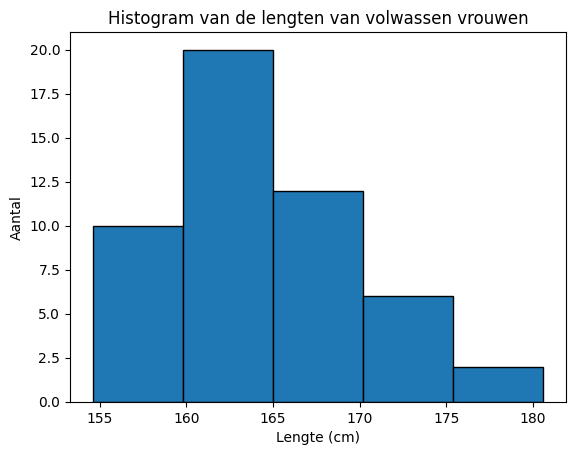

In [9]:
import matplotlib.pyplot as plt
plt.hist(lengten_volwassen_vrouwen, bins=5, edgecolor='black')
plt.title('Histogram van de lengten van volwassen vrouwen')
plt.xlabel('Lengte (cm)')
plt.ylabel('Aantal')
plt.show()

In [ ]:
# Antwoord: ik kies de normale verdeling

Leg uit dat wat [density estimation](https://en.wikipedia.org/wiki/Density_estimation) is en waarom dit een manier is om een generatief model te maken.

In [ ]:
# Dit betreft het schatten van een model op basis van waargenomen data, oftewel het benaderen van een niet-waarneembare onderliggende kansdichtheidsfunctie.

Er zijn vele antwoorden mogelijk, maar lengten zijn typisch normaal verdeeld. Hoewel de histogram misschien niet helemaal precies op een normale verdeling lijkt, gaan we daar wel vanuit. Maak een schatting van de parameters van een normale verdeling en genereer nog tien lengten. 

In [ ]:
# Antwoord: 

Het is goed mogelijk dat je het gemiddelde van de waarden in `lengten_volwassen_vrouwen` hebt genomen als schatting voor het gemiddelde van de normale verdeling. Dit is een unbiased estimator voor het gemiddelde van een normale verdeling. Bedenk een biased estimator voor het gemiddelde van een normale verdeling met een lagere variantie.

In [ ]:
# Antwoord: ...

## Gaussian Mixture Models (GMM)
Tot nu toe hebben we alleen de lengten van vrouwen bekeken. De variabele `lengten` bevat lengten van honderd mensen. We laten [intersexe](https://nl.wikipedia.org/wiki/Intersekse) personen even buiten beschouwing, om het model te vereenvoudigen. 

In [28]:
import pandas as pd

# Download van https://www.kaggle.com/datasets/saranpannasuriyaporn/male-female-height-and-weight
data = pd.read_csv("humans.csv")
lengten = data['Height']
lengten = lengten[lengten < 300]

We voeren eerst een kleine EDA uit, door een histogram te maken van de data. 

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.,   1.,   1.,   1.,   2.,   5.,
          1.,  13.,  11.,  18.,  22.,  23.,  41.,  48.,  63.,  59.,  74.,
         77.,  86., 103., 100., 111., 101., 132., 118., 126., 110., 122.,
        114., 129., 110., 127., 130., 133., 116., 101.,  91., 101.,  52.,
         50.,  49.,  37.,  22.,  20.,  13.,  10.,  10.,   3.,   2.,   3.,
          3.]),
 array([ 25.68  ,  27.4499,  29.2198,  30.9897,  32.7596,  34.5295,
         36.2994,  38.0693,  39.8392,  41.6091,  43.379 ,  45.1489,
         46.9188,  48.6887,  50.4586,  52.2285,  53.9984,  55.7683,
         57.5382,  59.3081,  61.078 ,  62.8479,  64.6178,  66.3877,
         68.1576,  69.9275,  71.6974,  73.4673

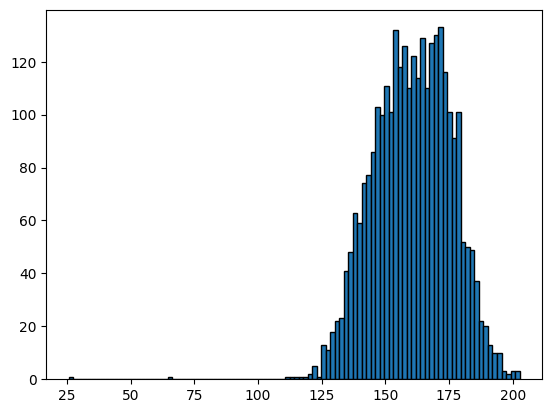

In [33]:
# histogram! He, die heeft een platte top...
# Antwoord: 
# make a histogram of the data
plt.hist(lengten, bins=100, edgecolor='black')

Dit is geen normale verdeling. Dit is een combinatie van twee normale verdelingen. Vind de parameters van deze twee normale verdelingen en genereer tien nieuwe lengten.

In [35]:
# Antwoord:

from sklearn.mixture import GaussianMixture
import numpy as np

# Reshape data for GMM
lengten = np.array(lengten).reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=2, random_state=0).fit(lengten)

# Generate new lengths
new_lengths, _ = gmm.sample(10)
print(new_lengths.flatten())

[158.69729271 168.37280795 122.80214019 165.75670513 139.80334929
 190.82293384 183.65657868 165.61361302 196.68056361 181.76973318]


Vergelijk de shape parameters met tabel 1 uit het [paper](https://link.springer.com/article/10.1007/s12070-012-0477-x) waarop deze data gebaseerd is. 

In [36]:
# Antwoord:
gmm.means_

array([[149.85335361],
       [170.76459407]])